In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error, mean_squared_error
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from scipy import stats

In [2]:
OUTPUT_DIR = r"C:\Courses\Innopolis\2026\ВЭД\Данные2"

In [3]:
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv")

df_suppliers = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
    .loc[:, ["supplier_id", "country_id", "years_of_relationship", "maturity_score"]]
)

df_countries = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_countries.csv")
    .loc[:, ["country_id", "country_risk_base", "sanctions_risk", "port_efficiency_base", "avg_customs_days"]]
)

df_products = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_products.csv")
    .loc[:, ["product_id", "category_id"]]
)

df_transport_modes = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_transport_modes.csv")
    .loc[:, ["transport_mode_id", "avg_transit_days", "delay_probability"]]
)

df = (
    df_po
    .merge(df_suppliers, how = "left", on = "supplier_id")
    .merge(df_countries, how = "left", on = "country_id")
    .merge(df_products, how = "left", on = "product_id")
    .merge(df_transport_modes, how = "left", on = "transport_mode_id")
)

In [4]:
df.columns

Index(['po_id', 'order_date', 'supplier_id', 'product_id', 'transport_mode_id',
       'origin_port_id', 'destination_port_id', 'quantity', 'unit_price_usd',
       'total_value_usd', 'currency_code', 'fx_rate_to_usd',
       'total_value_local', 'freight_cost_usd', 'insurance_cost_usd',
       'customs_duty_usd', 'incoterm', 'payment_method',
       'expected_delivery_days', 'actual_delivery_days',
       'port_congestion_at_order', 'shock_index_at_order',
       'supplier_reliability', 'final_state', 'is_fraud', 'fraud_type',
       'country_id', 'years_of_relationship', 'maturity_score',
       'country_risk_base', 'sanctions_risk', 'port_efficiency_base',
       'avg_customs_days', 'category_id', 'avg_transit_days',
       'delay_probability'],
      dtype='object')

In [5]:
id_cols = ["po_id"]
cat_cols = [
    #"supplier_id", 
    #"product_id", 
    "transport_mode_id",
    "category_id",
    #"origin_port_id", 
    #"destination_port_id", 
    "country_id", 
    "payment_method"
]

num_cols = [
    #"quantity", 
    #"unit_price_usd", 
    #"freight_cost_usd", 
    #"insurance_cost_usd",
    #"customs_duty_usd",
    "avg_customs_days",
    "avg_transit_days",
    "port_efficiency_base",
    "country_risk_base",
    "port_congestion_at_order", 
    "shock_index_at_order",
    "years_of_relationship",
    "supplier_reliability",
    "delay_probability",
    #"expected_delivery_days", 
    #"actual_delivery_days", 
    
    
]
target_col = ["actual_delivery_days"]

In [6]:
data = df.copy()
data = data.sort_values(by = "po_id")
data = data.set_index("po_id")
data = data[(data["is_fraud"] == False)&(data["actual_delivery_days"].notna())]
data = data[num_cols + cat_cols + target_col].dropna()
#data["delay_days"] = data["actual_delivery_days"] - data["expected_delivery_days"]

In [7]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
#train_data = train_data.dropna()
#test_data = test_data.dropna()
X_train = train_data[num_cols + cat_cols]
X_test = test_data[num_cols + cat_cols]
y_train = train_data[target_col]
y_test = test_data[target_col]

In [8]:
train_data.shape

(1816, 14)

In [9]:
test_data.shape

(455, 14)

In [10]:
def evaluate_model(y_pred, y_test):
    print("MAE:", round(mean_absolute_error(y_test, y_pred),4))
    print("MAPE:", round(mean_absolute_percentage_error(y_test, y_pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
    print("R2:", round(r2_score(y_test, y_pred), 4))

def get_coefs(model):
    return pd.DataFrame(zip(model.named_steps["preprocessor"].get_feature_names_out(), model.named_steps["model"].coef_))

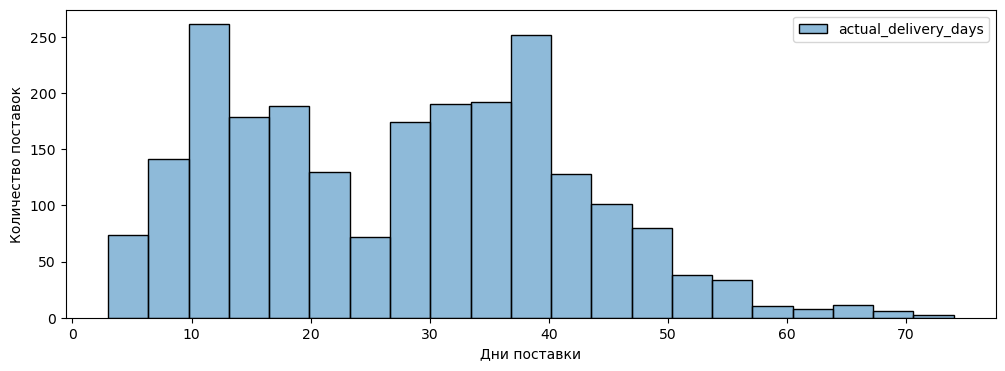

In [11]:
fig, ax = plt.subplots(1,1,figsize = (12,4))
sns.histplot(data[target_col])
ax.set_xlabel("Дни поставки")
ax.set_ylabel("Количество поставок")
plt.show()

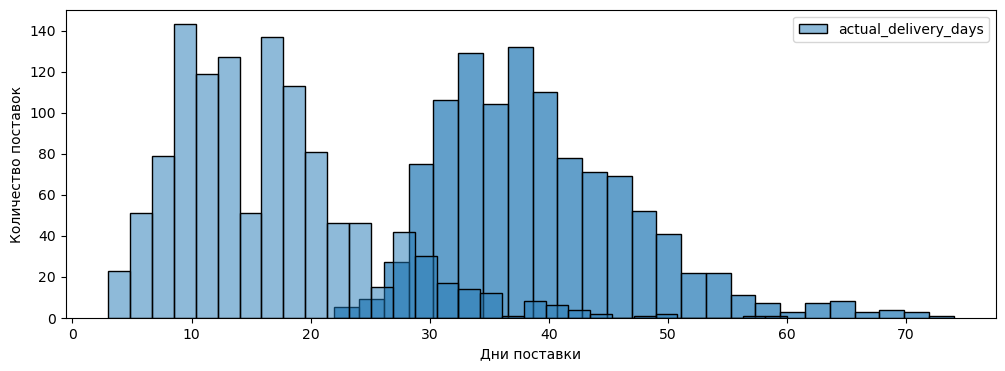

In [24]:
fig, ax = plt.subplots(1,1,figsize = (12,4))
sns.histplot(data.loc[data['transport_mode_id'].isin([1,2]), target_col], color="purple", edgecolor="black", alpha=0.7, ax = ax)
sns.histplot(data.loc[~data['transport_mode_id'].isin([1,2]), target_col], color = "r", ax = ax)
ax.set_xlabel("Дни поставки")
ax.set_ylabel("Количество поставок")
plt.show()

In [132]:
data[target_col].describe().T

,count,mean,std,min,25%,50%,75%,max
actual_delivery_days,2271.0,27.546455,14.037283,3.0,15.0,29.0,38.0,74.0


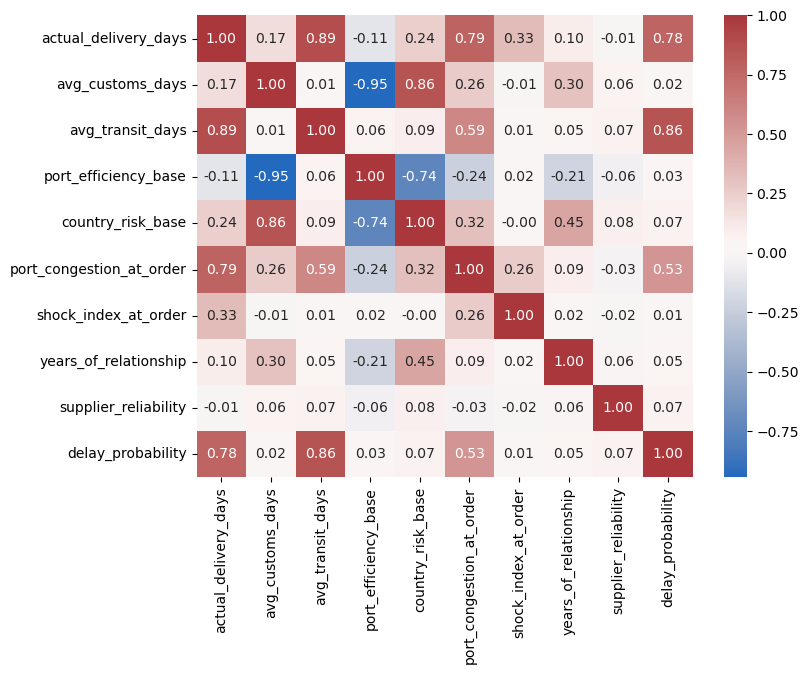

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (8,6))
sns.heatmap(data[target_col + num_cols].corr(), name)
plt.show()

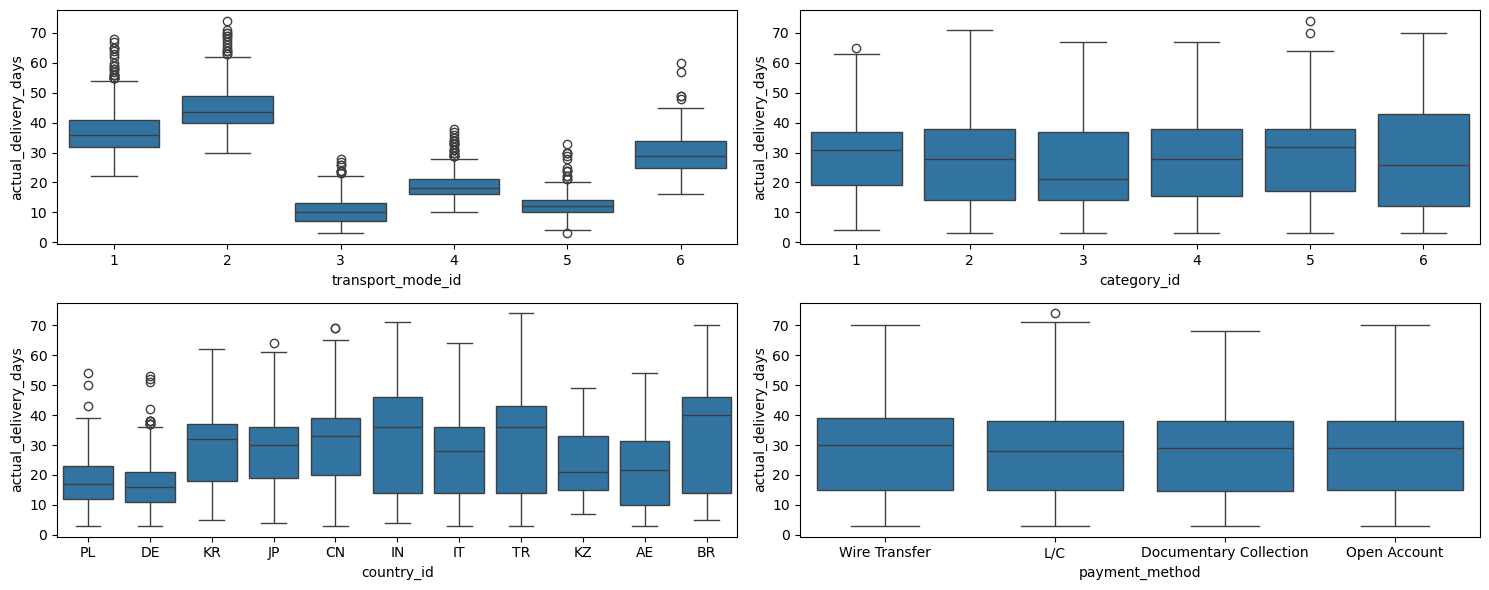

In [134]:
fig, axes = plt.subplots(2,2, figsize = (15,6))
for i, ax in enumerate(axes.flatten()):
    sns.boxplot(x = cat_cols[i], y = target_col[0], data = data, ax = ax)
plt.tight_layout()
plt.show()

# Определим изначальное качество предсказания сроков доставки

In [ ]:
baseline_df= df_po[["actual_delivery_days", "expected_delivery_days"]].dropna()
evaluate_model(baseline_df["actual_delivery_days"].values, baseline_df["expected_delivery_days"].values)

MAE: 5.7318
MAPE: 0.2864
RMSE: 8.0875
R2: 0.4275


# Линейная регрессия с 1 регрессором

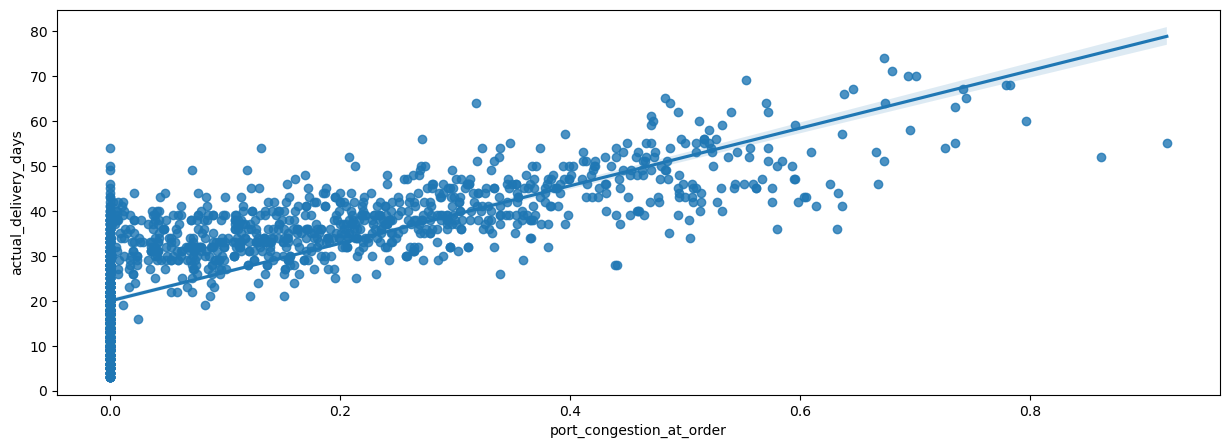

In [135]:
fig, ax = plt.subplots(1,1,figsize = (15,5))
sns.regplot(x = num_cols[4], y = target_col[0], data = train_data)
plt.show()

In [136]:
model1 = ols(f"{target_col[0]} ~ {num_cols[4]}", data = train_data).fit()
print(model1.summary())

                             OLS Regression Results                             
Dep. Variable:     actual_delivery_days   R-squared:                       0.613
Model:                              OLS   Adj. R-squared:                  0.613
Method:                   Least Squares   F-statistic:                     2873.
Date:                  Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                          15:12:09   Log-Likelihood:                -6506.4
No. Observations:                  1816   AIC:                         1.302e+04
Df Residuals:                      1814   BIC:                         1.303e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Inte

In [137]:
y_pred_train = model1.predict(X_train[num_cols[4]]).values
y_pred_test = model1.predict(X_test[num_cols[4]]).values

print("Evaluate train sample")
evaluate_model(y_pred_train, y_train.values)

print("Evaluate test sample")
evaluate_model(y_pred_test, y_test.values)

Evaluate train sample
MAE: 7.0896
MAPE: 0.4404
RMSE: 8.705
R2: 0.613
Evaluate test sample
MAE: 7.1231
MAPE: 0.4457
RMSE: 8.6002
R2: 0.6329


# Линейная регрессия с 2 регрессорами

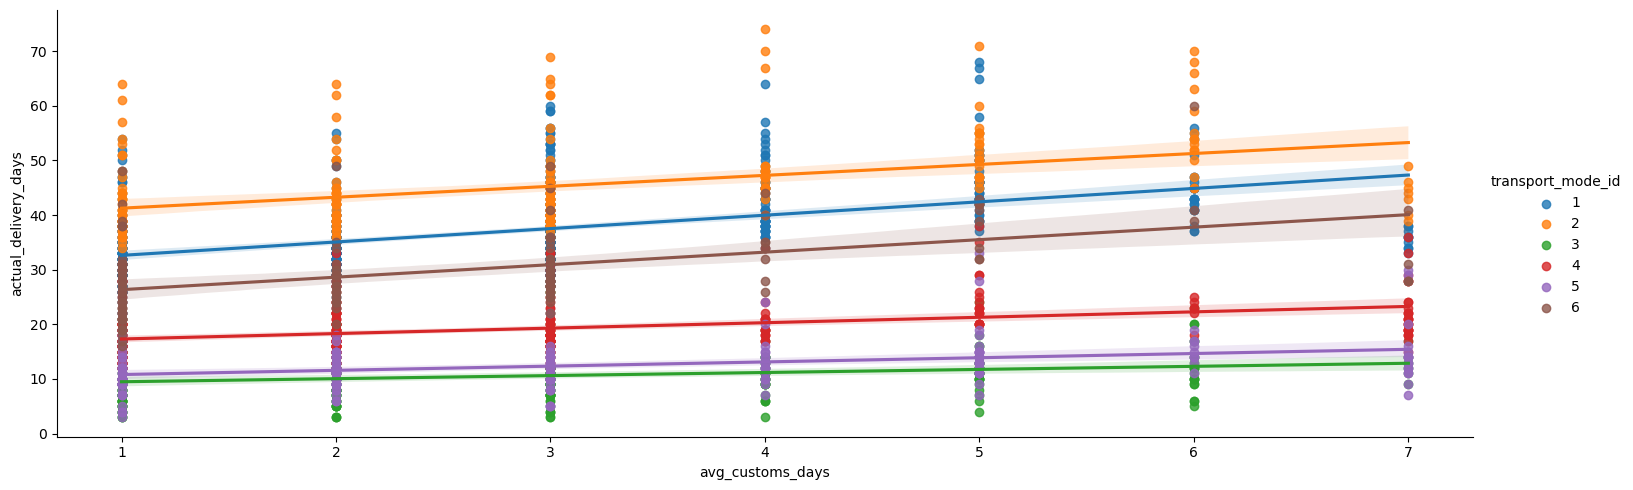

In [138]:
sns.lmplot(x = num_cols[0], y = target_col[0], data = train_data, hue = cat_cols[0], height = 5, aspect = 3)
plt.show()

In [139]:
model2 = ols(f"{target_col[0]} ~ {num_cols[0]} + C({cat_cols[0]})", data = data).fit()
print(model2.summary())

                             OLS Regression Results                             
Dep. Variable:     actual_delivery_days   R-squared:                       0.822
Model:                              OLS   Adj. R-squared:                  0.821
Method:                   Least Squares   F-statistic:                     1740.
Date:                  Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                          15:12:12   Log-Likelihood:                -7262.9
No. Observations:                  2271   AIC:                         1.454e+04
Df Residuals:                      2264   BIC:                         1.458e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

In [140]:
y_pred_train = model2.predict(X_train[[num_cols[0],cat_cols[0]]]).values
y_pred_test = model2.predict(X_test[[num_cols[0],cat_cols[0]]]).values

print("Evaluate train sample")
evaluate_model(y_pred_train, y_train.values)

print("Evaluate test sample")
evaluate_model(y_pred_test, y_test.values)

Evaluate train sample
MAE: 4.2828
MAPE: 0.1973
RMSE: 5.899
R2: 0.8223
Evaluate test sample
MAE: 4.2094
MAPE: 0.1951
RMSE: 6.0276
R2: 0.8197


# Линейная регрессия со всеми регрессорами

In [30]:
# preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

linreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linreg_model.fit(X_train, y_train)

y_pred_train = linreg_model.predict(X_train.dropna())
y_pred_test = linreg_model.predict(X_test.dropna())

print("Evaluate train sample")
evaluate_model(y_pred_train, y_train.values)

print("Evaluate test sample")
evaluate_model(y_pred_test, y_test.values)

Evaluate train sample
MAE: 2.017
MAPE: 0.1132
RMSE: 2.6625
R2: 0.9638
Evaluate test sample
MAE: 2.1346
MAPE: 0.1213
RMSE: 2.7438
R2: 0.9626


In [145]:
data.shape

(2271, 14)

In [159]:
data["predicted_delivery_days"] = np.round(linreg_model.predict(data[num_cols + cat_cols]),0)

In [164]:
df_po = df_po.merge(data["predicted_delivery_days"].reset_index(drop = False), how = "left", on = "po_id")

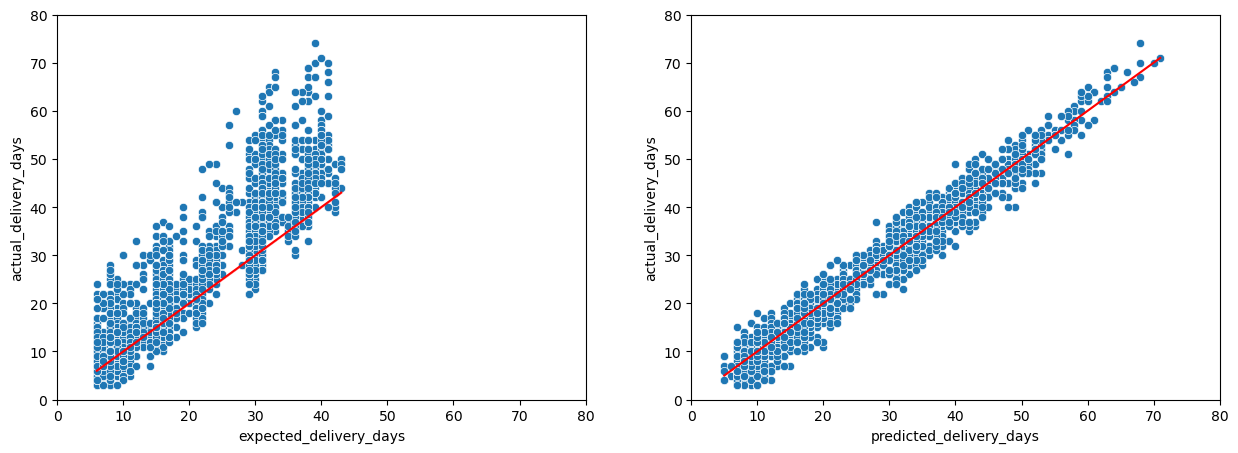

In [173]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
sns.scatterplot(x = "expected_delivery_days", y = "actual_delivery_days", data = df_po, ax = ax[0])
sns.lineplot(x = "expected_delivery_days", y = "expected_delivery_days",data = df_po, ax = ax[0], color = 'red')
sns.scatterplot(x = "predicted_delivery_days", y = "actual_delivery_days", data = df_po, ax = ax[1])
sns.lineplot(x = "predicted_delivery_days", y = "predicted_delivery_days",data = df_po, ax = ax[1], color = 'red')
ax[0].set_xlim(0, 80)
ax[0].set_ylim(0, 80)
ax[1].set_xlim(0, 80)
ax[1].set_ylim(0, 80)
plt.show()

# Гребневая регрессия

In [74]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

print("Ridge Regression:")
evaluate_model(ridge_model, X_test, y_test)

Ridge Regression:
MAE: 2.1235088762414036
MAPE: 485419862145548.44
RMSE: 2.815596264339252
R2: 0.7835974580633729


In [80]:
get_coefs(ridge_model)

,0,1
0,num__quantity,0.022654
1,num__unit_price_usd,0.405064
2,num__freight_cost_usd,-0.112622
3,num__insurance_cost_usd,0.204527
4,num__customs_duty_usd,-0.043728
...,...,...
83,cat__incoterm_Fob,0.283691
84,cat__payment_method_Documentary Collection,0.014740
85,cat__payment_method_L/C,-0.028997
86,cat__payment_method_Open Account,-0.241306


# Лассо регрессия

In [32]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

lasso_model.fit(X_train, y_train)

y_pred_train = lasso_model.predict(X_train.dropna())
y_pred_test = lasso_model.predict(X_test.dropna())

print("Evaluate train sample")
evaluate_model(y_pred_train, y_train.values)

print("Evaluate test sample")
evaluate_model(y_pred_test, y_test.values)

Evaluate train sample
MAE: 2.0406
MAPE: 0.1154
RMSE: 2.6935
R2: 0.9629
Evaluate test sample
MAE: 2.111
MAPE: 0.1209
RMSE: 2.7529
R2: 0.9624


In [36]:
get_coefs(lasso_model)[get_coefs(lasso_model)[1]!=0]

,0,1
0,num__avg_customs_days,1.218891
1,num__avg_transit_days,10.155818
2,num__port_efficiency_base,-0.137407
3,num__country_risk_base,0.105421
4,num__port_congestion_at_order,3.443542
5,num__shock_index_at_order,3.579397
6,num__years_of_relationship,0.048515
7,num__supplier_reliability,-0.674606
8,num__delay_probability,0.115409
